In [1]:
import pandas as pd

dataset=pd.read_csv("data/AEP_hourly.csv")
dataset.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [2]:
dataset.shape

(121273, 2)

In [3]:
sample_data=dataset.sample(frac=0.2,random_state=42)
sample_data.shape

(24255, 2)

Text(0.5, 1.0, 'Distribution of AEP_MW')

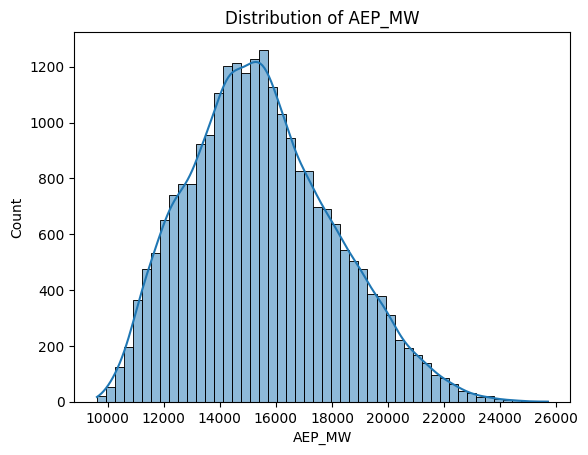

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(sample_data['AEP_MW'], bins=50, kde=True)
plt.title('Distribution of AEP_MW')

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

scaler = MinMaxScaler()

dataset["AEP_MW_scaled"] = scaler.fit_transform(dataset['AEP_MW'].values.reshape(-1, 1))


In [6]:
dataset['AEP_MW_lag_1'] = dataset['AEP_MW_scaled'].shift(1)
dataset['AEP_MW_lag_2'] = dataset['AEP_MW_scaled'].shift(2)
dataset['AEP_MW_lag_24'] = dataset['AEP_MW_scaled'].shift(24)  # Previous day same hour

In [7]:
dataset.head()

,Datetime,AEP_MW,AEP_MW_scaled,AEP_MW_lag_1,AEP_MW_lag_2,AEP_MW_lag_24
0,2004-12-31 01:00:00,13478.0,0.241839,NaN,NaN,NaN
1,2004-12-31 02:00:00,12865.0,0.203798,0.241839,NaN,NaN
2,2004-12-31 03:00:00,12577.0,0.185925,0.203798,0.241839,NaN
3,2004-12-31 04:00:00,12517.0,0.182202,0.185925,0.203798,NaN
4,2004-12-31 05:00:00,12670.0,0.191697,0.182202,0.185925,NaN


In [8]:
dataset.dropna(inplace=True)

In [9]:
dataset['Datetime'] = pd.to_datetime(dataset['Datetime'])

# Extract components of the Datetime column
dataset['Year'] = dataset['Datetime'].dt.year
dataset['Month'] = dataset['Datetime'].dt.month
dataset['Day'] = dataset['Datetime'].dt.day
dataset['Hour'] = dataset['Datetime'].dt.hour

In [10]:
# Add cyclic encoding for temporal features
# This treats periodic features (Month, Hour, Day) as circular

# Month: Cyclical encoding (12 months in a year)
dataset['Month_sin'] = np.sin(2 * np.pi * dataset['Month'] / 12)
dataset['Month_cos'] = np.cos(2 * np.pi * dataset['Month'] / 12)

# Hour: Cyclical encoding (24 hours in a day)
dataset['Hour_sin'] = np.sin(2 * np.pi * dataset['Hour'] / 24)
dataset['Hour_cos'] = np.cos(2 * np.pi * dataset['Hour'] / 24)

# Day of week from Datetime
dataset['DayOfWeek'] = dataset['Datetime'].dt.dayofweek
dataset['DayOfWeek_sin'] = np.sin(2 * np.pi * dataset['DayOfWeek'] / 7)
dataset['DayOfWeek_cos'] = np.cos(2 * np.pi * dataset['DayOfWeek'] / 7)

print("Cyclic features added successfully")
print(dataset[['Month', 'Month_sin', 'Month_cos', 'Hour', 'Hour_sin', 'Hour_cos']].head())


Cyclic features added successfully
    Month     Month_sin  Month_cos  Hour  Hour_sin  Hour_cos
24     12 -2.449294e-16        1.0     1  0.258819  0.965926
25     12 -2.449294e-16        1.0     2  0.500000  0.866025
26     12 -2.449294e-16        1.0     3  0.707107  0.707107
27     12 -2.449294e-16        1.0     4  0.866025  0.500000
28     12 -2.449294e-16        1.0     5  0.965926  0.258819


In [11]:
dataset.head()

,Datetime,AEP_MW,AEP_MW_scaled,AEP_MW_lag_1,AEP_MW_lag_2,AEP_MW_lag_24,Year,Month,Day,Hour,Month_sin,Month_cos,Hour_sin,Hour_cos,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
24,2004-12-30 01:00:00,14097.0,0.280253,0.205474,0.241839,0.241839,2004,12,30,1,-2.449294e-16,1.0,0.258819,0.965926,3,0.433884,-0.900969
25,2004-12-30 02:00:00,13667.0,0.253568,0.280253,0.205474,0.203798,2004,12,30,2,-2.449294e-16,1.0,0.500000,0.866025,3,0.433884,-0.900969
26,2004-12-30 03:00:00,13451.0,0.240164,0.253568,0.280253,0.185925,2004,12,30,3,-2.449294e-16,1.0,0.707107,0.707107,3,0.433884,-0.900969
27,2004-12-30 04:00:00,13379.0,0.235696,0.240164,0.253568,0.182202,2004,12,30,4,-2.449294e-16,1.0,0.866025,0.500000,3,0.433884,-0.900969
28,2004-12-30 05:00:00,13506.0,0.243577,0.235696,0.240164,0.191697,2004,12,30,5,-2.449294e-16,1.0,0.965926,0.258819,3,0.433884,-0.900969


In [12]:
feature_columns = [
    'Month_sin', 'Month_cos',           # Cyclic month
    'Hour_sin', 'Hour_cos',             # Cyclic hour
    'DayOfWeek_sin', 'DayOfWeek_cos',   # Cyclic day of week
    'AEP_MW_lag_1', 'AEP_MW_lag_2',     # Recent lags
    'AEP_MW_lag_24'                     # Previous day same hour (seasonality)
]

# Drop rows with NaN in any feature column
dataset_clean = dataset[feature_columns + ['AEP_MW_scaled']].dropna()

X = dataset_clean[feature_columns].values
y = dataset_clean['AEP_MW_scaled'].values


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}")


feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)  # Use training stats for test

Train set: X_train=(96999, 9), y_train=(96999,)
Test set: X_test=(24250, 9), y_test=(24250,)


In [14]:
# TensorFlow/Keras uses NumPy arrays directly, so PyTorch tensors are not needed.
# Convert to float32 for efficient neural-network training.
X_train_tf = X_train_scaled.astype('float32')
X_test_tf = X_test_scaled.astype('float32')
y_train_tf = y_train.astype('float32').reshape(-1, 1)
y_test_tf = y_test.astype('float32').reshape(-1, 1)

print("TensorFlow-ready shapes:")
print("X_train:", X_train_tf.shape, "y_train:", y_train_tf.shape)
print("X_test :", X_test_tf.shape, "y_test :", y_test_tf.shape)


TensorFlow-ready shapes:
X_train: (96999, 9) y_train: (96999, 1)
X_test : (24250, 9) y_test : (24250, 1)


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

def build_energy_model(input_size):
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.30),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.20),

        layers.Dense(32, activation='relu'),

        # Regression output: one continuous value, so no output activation
        layers.Dense(1)
    ], name='EnergyConsumptionModel')

    return model


In [16]:
input_size = X_train_tf.shape[1]
model = build_energy_model(input_size)

model.summary()


Model: "EnergyConsumptionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
# AdamW is the TensorFlow/Keras equivalent of the optimizer used in the PyTorch version.
optimizer = keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=1e-5
)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='mae'),
        keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

# Reduce learning rate when validation loss stops improving.
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=10,
    verbose=1
)


In [18]:
epochs = 200

history = model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_test_tf, y_test_tf),
    epochs=epochs,
    batch_size=256,
    callbacks=[lr_scheduler],
    verbose=1
)

# Keep the same variable names used later for plotting.
train_losses = history.history['loss']
val_losses = history.history['val_loss']


Epoch 1/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0349 - mae: 0.1308 - rmse: 0.1868 - val_loss: 0.0149 - val_mae: 0.0964 - val_rmse: 0.1222 - learning_rate: 0.0010
Epoch 2/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0067 - mae: 0.0639 - rmse: 0.0819 - val_loss: 0.0024 - val_mae: 0.0385 - val_rmse: 0.0491 - learning_rate: 0.0010
Epoch 3/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0039 - mae: 0.0483 - rmse: 0.0621 - val_loss: 0.0017 - val_mae: 0.0316 - val_rmse: 0.0411 - learning_rate: 0.0010
Epoch 4/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0028 - mae: 0.0411 - rmse: 0.0530 - val_loss: 0.0016 - val_mae: 0.0309 - val_rmse: 0.0403 - learning_rate: 0.0010
Epoch 5/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - mae: 0.0373 - rmse: 0.0485 - val_loss: 0.0015 - val_mae: 0.0292 - val_rmse: 0.0383 - learning_rate: 0.0010
Epoch 6/200
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0021 - mae: 0.0352 - rmse: 0.0458 - val_loss: 0.0014

In [19]:
# Predict on the test set.
y_pred_test_np = model.predict(X_test_tf, verbose=0)

# Convert scaled predictions and targets back to original MW units.
y_pred_original = scaler.inverse_transform(y_pred_test_np)
y_test_original = scaler.inverse_transform(y_test_tf)

print(f"Predicted range: {y_pred_original.min():.2f} - {y_pred_original.max():.2f} MW")
print(f"Actual range:    {y_test_original.min():.2f} - {y_test_original.max():.2f} MW")


Predicted range: 10841.97 - 23264.72 MW
Actual range:    9581.00 - 24739.00 MW


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

# Avoid division by zero when calculating percentage error.
actual_flat = y_test_original.flatten()
pred_flat = y_pred_original.flatten()
nonzero_mask = actual_flat != 0

absolute_percentage_error = np.abs(
    (actual_flat[nonzero_mask] - pred_flat[nonzero_mask]) /
    actual_flat[nonzero_mask]
) * 100

mape = np.mean(absolute_percentage_error)

# For regression there is no standard classification-style "accuracy".
# These tolerance accuracies report the percentage of predictions whose
# absolute percentage error is within a chosen threshold.
accuracy_within_5pct = np.mean(absolute_percentage_error <= 5) * 100
accuracy_within_10pct = np.mean(absolute_percentage_error <= 10) * 100

print("\n===== Test-set Regression Metrics =====")
print(f"MSE:                  {mse:,.2f}")
print(f"RMSE:                 {rmse:,.2f} MW")
print(f"MAE:                  {mae:,.2f} MW")
print(f"R² score:             {r2:.4f}")
print(f"MAPE:                 {mape:.2f}%")
print(f"Accuracy within ±5%:  {accuracy_within_5pct:.2f}%")
print(f"Accuracy within ±10%: {accuracy_within_10pct:.2f}%")

print("\nSample predictions vs actual (first 20 samples):")
sample_actual = actual_flat[:20]
sample_pred = pred_flat[:20]

comparison = pd.DataFrame({
    'Actual_MW': sample_actual,
    'Predicted_MW': sample_pred,
    'Absolute_Error_MW': np.abs(sample_actual - sample_pred),
    'Error_%': np.where(
        sample_actual != 0,
        np.abs((sample_actual - sample_pred) / sample_actual) * 100,
        np.nan
    )
})
print(comparison)



===== Test-set Regression Metrics =====
MSE:                  276,720.06
RMSE:                 526.04 MW
MAE:                  399.97 MW
R² score:             0.9580
MAPE:                 2.88%
Accuracy within ±5%:  83.16%
Accuracy within ±10%: 97.56%

Sample predictions vs actual (first 20 samples):
    Actual_MW  Predicted_MW  Absolute_Error_MW    Error_%
0     15317.0  15283.443359          33.556641   0.219081
1     14786.0  14937.168945         151.168945   1.022379
2     14391.0  14597.434570         206.434570   1.434470
3     14384.0  14443.721680          59.721680   0.415195
4     14479.0  14657.168945         178.168945   1.230533
5     15273.0  14802.848633         470.151367   3.078317
6     15809.0  15525.379883         283.620117   1.794042
7     15821.0  15907.452148          86.452148   0.546439
8     15624.0  15602.178711          21.821289   0.139665
9     15188.0  15105.751953          82.248047   0.541533
10    14652.0  14244.923828         407.076172   2.778298
1

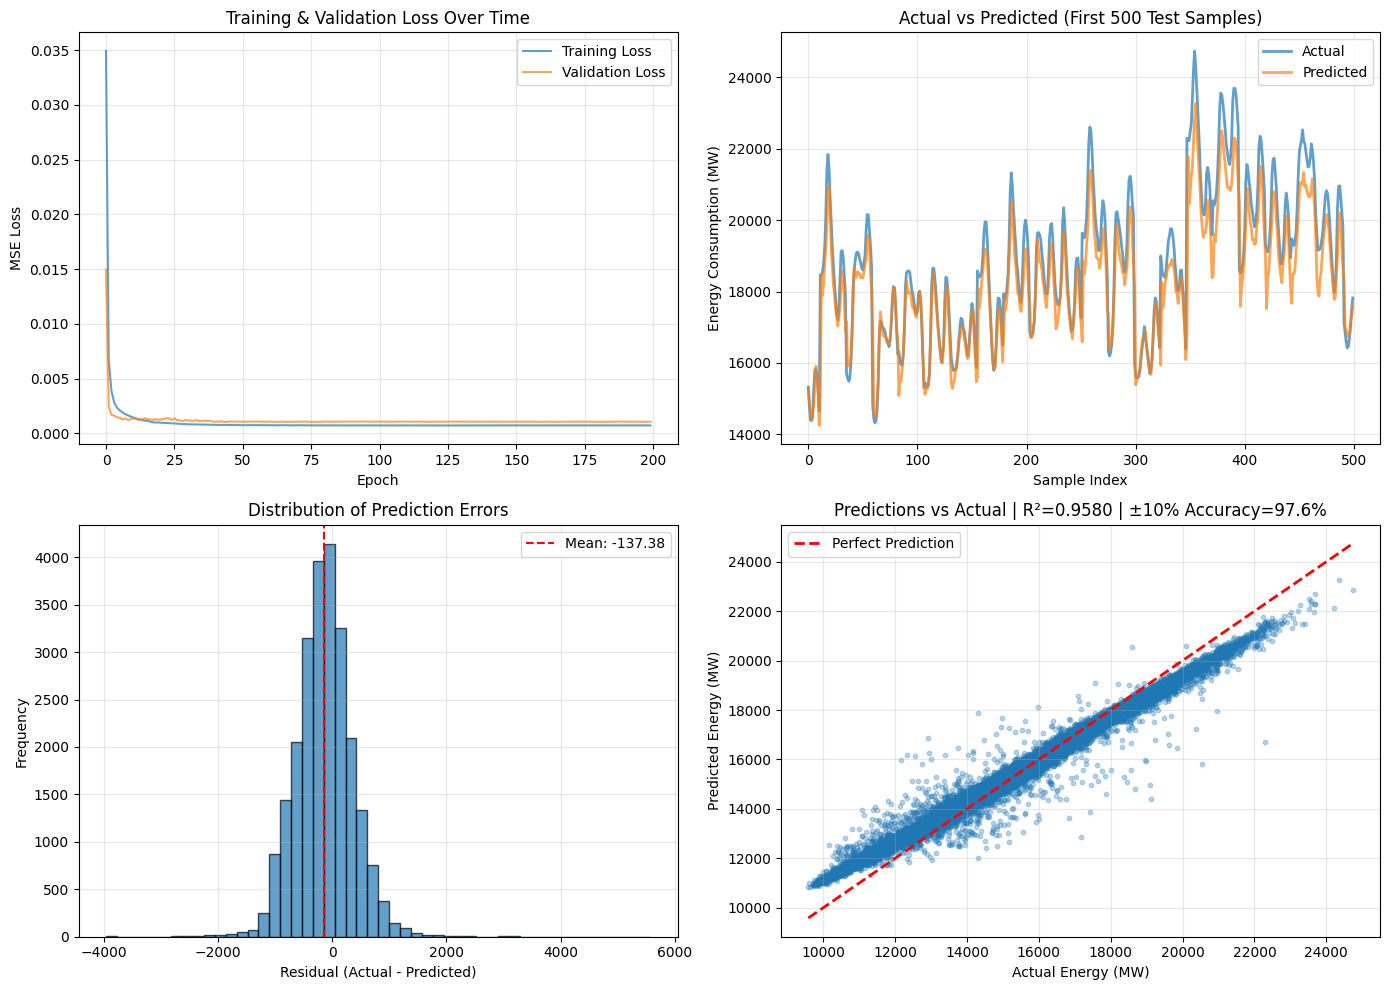

In [21]:
# Visualization: training curves and predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training Loss Curve
axes[0, 0].plot(train_losses, label='Training Loss', alpha=0.7)
axes[0, 0].plot(val_losses, label='Validation Loss', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training & Validation Loss Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (first 500 samples)
axes[0, 1].plot(y_test_original[:500], label='Actual', alpha=0.7, linewidth=2)
axes[0, 1].plot(y_pred_original[:500], label='Predicted', alpha=0.7, linewidth=2)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Energy Consumption (MW)')
axes[0, 1].set_title('Actual vs Predicted (First 500 Test Samples)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals Distribution
residuals = y_test_original.flatten() - y_pred_original.flatten()
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(
    residuals.mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {residuals.mean():.2f}'
)
axes[1, 0].set_xlabel('Residual (Actual - Predicted)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Prediction Errors')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter: Predicted vs Actual
axes[1, 1].scatter(y_test_original, y_pred_original, alpha=0.3, s=10)
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
axes[1, 1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)
axes[1, 1].set_xlabel('Actual Energy (MW)')
axes[1, 1].set_ylabel('Predicted Energy (MW)')
axes[1, 1].set_title(
    f'Predictions vs Actual | R²={r2:.4f} | ±10% Accuracy={accuracy_within_10pct:.1f}%'
)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
